#03: EDA analysis

## 01. Setup & Load

In [ ]:
from google.colab import drive
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:

df = pd.read_csv("/content/drive/MyDrive/DVA_Project/data/processed/cleaned_dataset.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1042384 entries, 0 to 1042383
Data columns (total 29 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   video_id               1042384 non-null  object 
 1   title                  1042384 non-null  object 
 2   publish_time           1042384 non-null  object 
 3   channel_id             1042384 non-null  object 
 4   channel_title          1042384 non-null  object 
 5   category_id            1042384 non-null  int64  
 6   trending_date          1042384 non-null  object 
 7   tags                   868694 non-null   object 
 8   views                  1042384 non-null  int64  
 9   likes                  1042384 non-null  int64  
 10  comments               1042384 non-null  int64  
 11  thumbnail_link         1042384 non-null  object 
 12  comments_disabled      1042384 non-null  bool   
 13  ratings_disabled       1042384 non-null  bool   
 14  description       

In [ ]:
df.describe()

,category_id,views,likes,comments,engagement_rate,time_to_trend,publish_hour,is_weekend,title_length,title_uppercase_ratio,title_has_exclamation,tag_count,has_tags,virality_score,like_ratio,comment_ratio
count,1.042384e+06,1.042384e+06,1.042384e+06,1.042384e+06,1.042227e+06,1.042384e+06,1.042384e+06,1.042384e+06,1.042384e+06,1.042384e+06,1.042384e+06,1.042384e+06,1.042384e+06,1.042384e+06,1.042200e+06,1.042218e+06
mean,1.944228e+01,2.545163e+06,1.245093e+05,8.735001e+03,5.526048e-02,2.753616e+00,1.325205e+01,2.784981e-01,5.544881e+01,2.155862e-01,1.506825e-01,1.610085e+01,8.333723e-01,7.599346e+05,5.158949e-02,3.672360e-03
std,6.521128e+00,7.642595e+06,3.913420e+05,6.654653e+04,3.928474e-02,2.312514e+00,6.232721e+00,4.482601e-01,2.300154e+01,1.836027e-01,3.577393e-01,1.239854e+01,3.726433e-01,2.224964e+06,3.690080e-02,5.099952e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.700000e+01,4.155158e+05,1.453000e+04,8.100000e+02,2.564722e-02,1.000000e+00,9.000000e+00,0.000000e+00,3.800000e+01,1.190476e-01,0.000000e+00,5.000000e+00,1.000000e+00,1.320043e+05,2.347384e-02,1.198788e-03
50%,2.200000e+01,8.923000e+05,3.766600e+04,2.107000e+03,4.835095e-02,2.000000e+00,1.500000e+01,0.000000e+00,5.100000e+01,1.538462e-01,0.000000e+00,1.600000e+01,1.000000e+00,2.872694e+05,4.522772e-02,2.513347e-03
75%,2.400000e+01,2.099583e+06,9.970600e+04,5.408000e+03,7.430828e-02,4.000000e+00,1.800000e+01,1.000000e+00,7.200000e+01,2.380952e-01,0.000000e+00,2.500000e+01,1.000000e+00,6.908400e+05,6.988578e-02,4.574689e-03
max,2.900000e+01,1.407644e+09,1.611524e+07,6.738565e+06,7.317551e-01,3.600000e+01,2.300000e+01,1.000000e+00,1.000000e+02,1.000000e+00,1.000000e+00,9.200000e+01,1.000000e+00,7.038218e+08,4.575602e-01,4.266585e-01


In [ ]:
df.shape

(1042384, 29)

## 02. Column Segregation

In [ ]:
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object','bool']).columns.tolist()

print("Numerical:", num_cols)
print("Categorical:", cat_cols)

Numerical: ['category_id', 'views', 'likes', 'comments', 'engagement_rate', 'time_to_trend', 'publish_hour', 'is_weekend', 'title_length', 'title_uppercase_ratio', 'title_has_exclamation', 'tag_count', 'has_tags', 'virality_score', 'like_ratio', 'comment_ratio']
Categorical: ['video_id', 'title', 'publish_time', 'channel_id', 'channel_title', 'trending_date', 'tags', 'thumbnail_link', 'comments_disabled', 'ratings_disabled', 'description', 'country', 'publish_day']


## 03. UNIVARIATE ANALYSIS

### 3.1 Numerical Features

#### Distribution

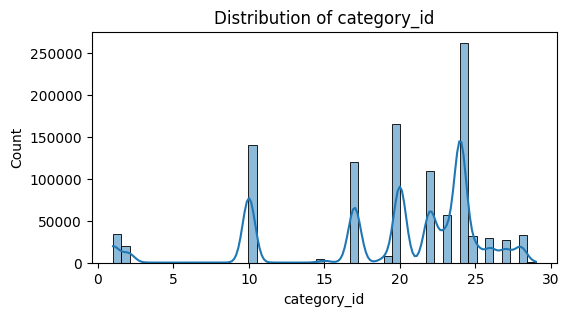

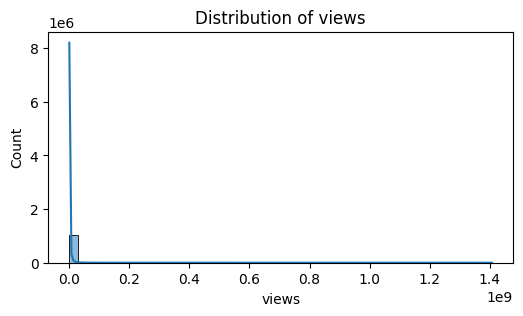

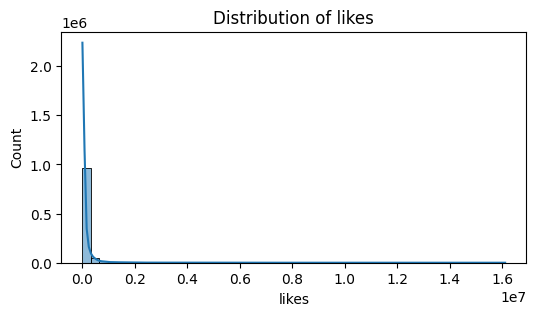

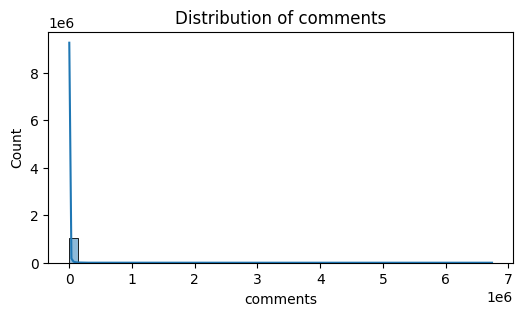

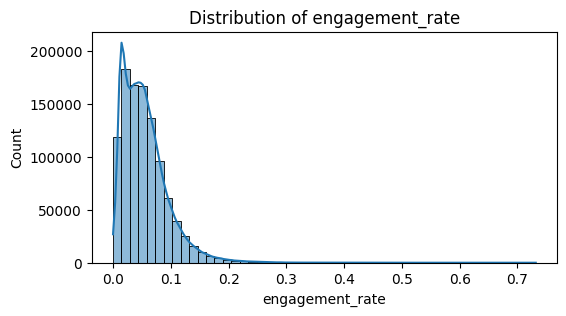

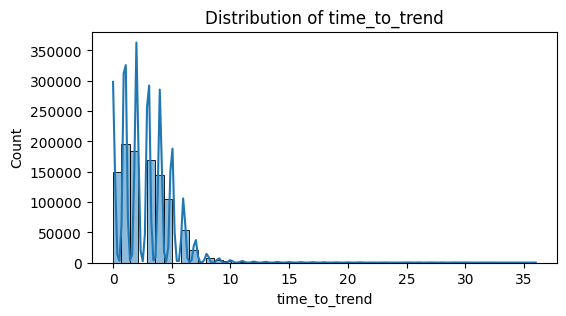

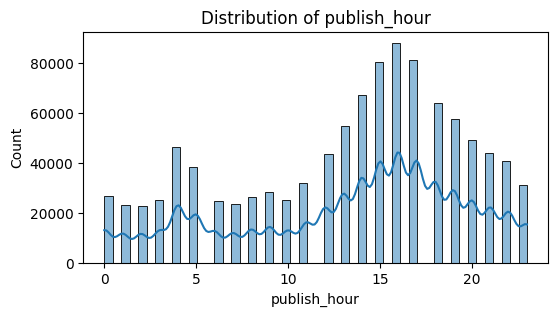

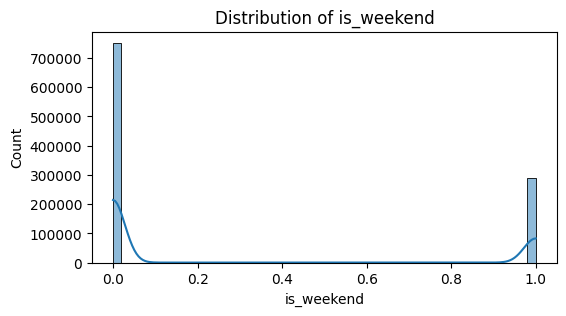

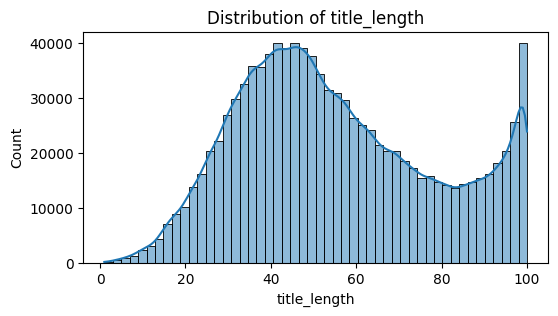

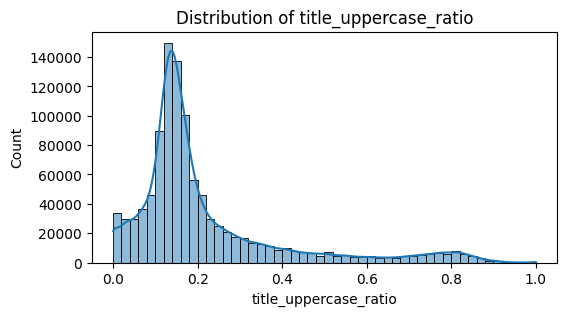

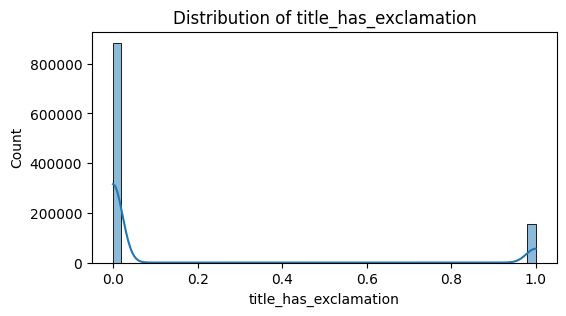

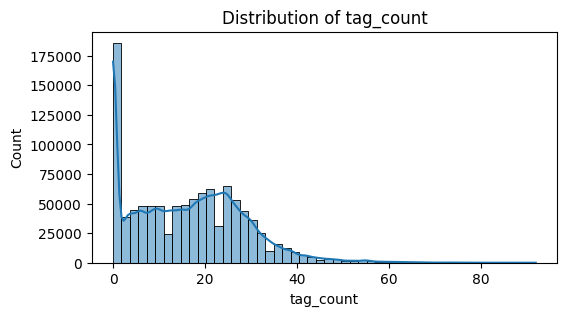

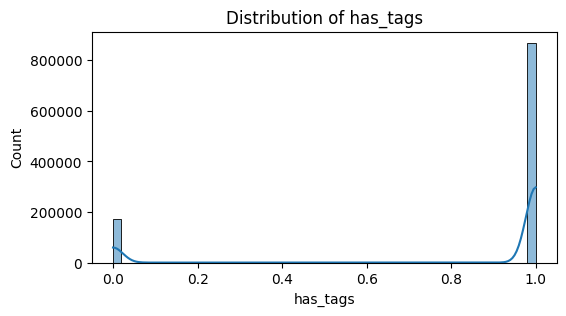

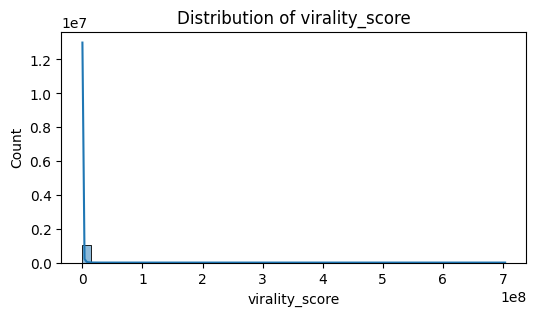

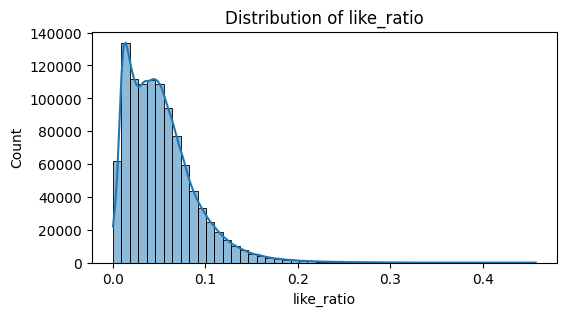

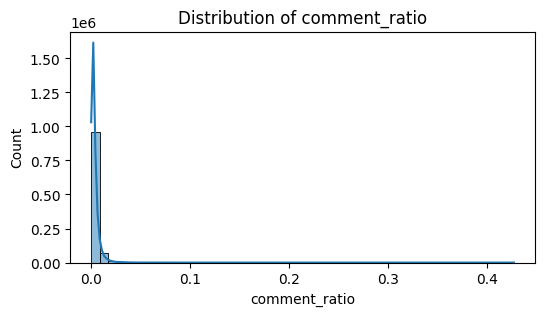

In [ ]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

####Skewness

In [ ]:
skewness = df[num_cols].skew().sort_values(ascending=False)
print(skewness)

virality_score           79.083091
comments                 47.802833
views                    27.997867
comment_ratio            14.854119
likes                    13.500348
time_to_trend             2.587083
title_has_exclamation     1.952921
title_uppercase_ratio     1.940929
engagement_rate           1.543212
like_ratio                1.430433
is_weekend                0.988276
tag_count                 0.533078
title_length              0.356936
publish_hour             -0.509927
category_id              -1.272784
has_tags                 -1.789234
dtype: float64


####Boxplots (Outliers)

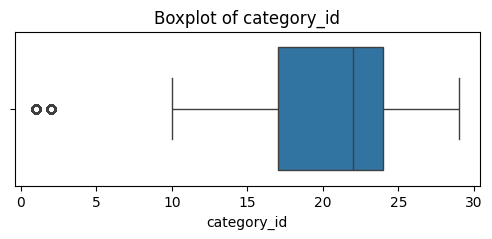

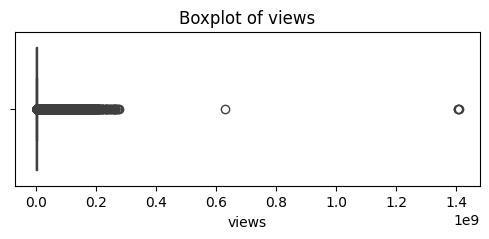

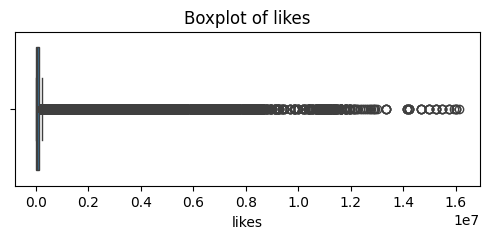

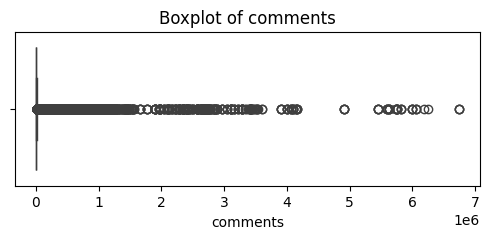

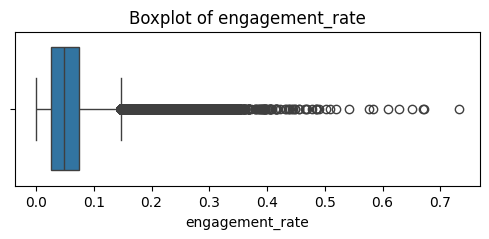

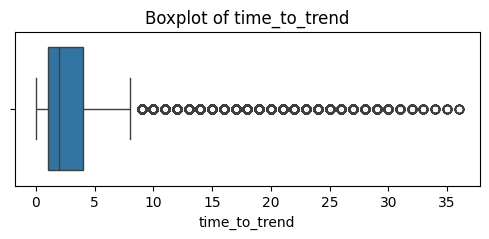

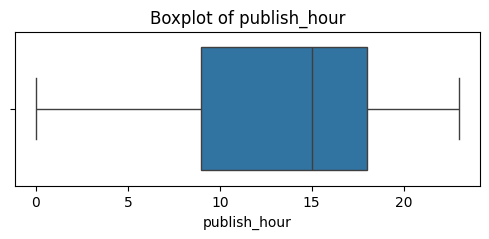

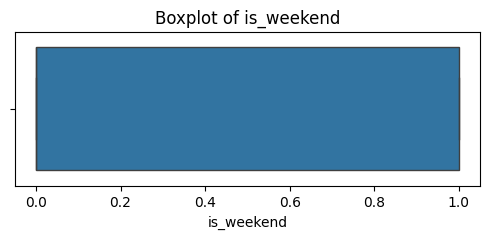

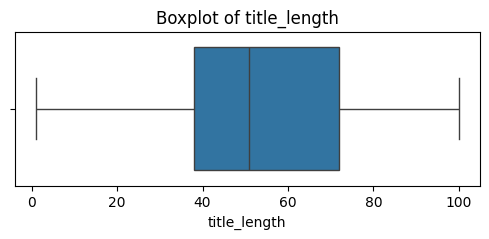

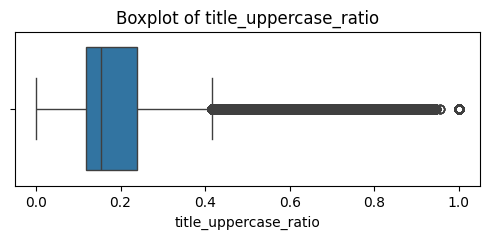

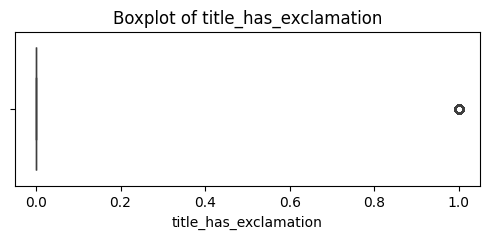

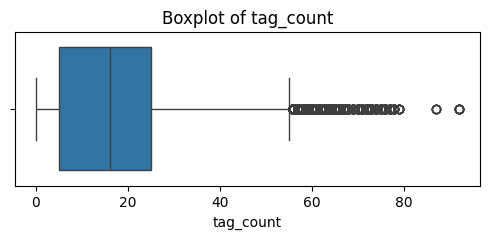

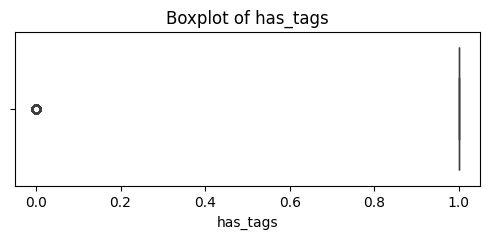

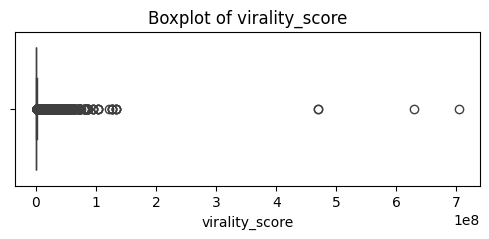

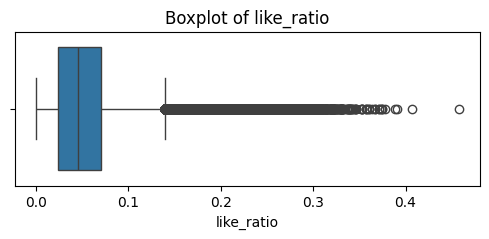

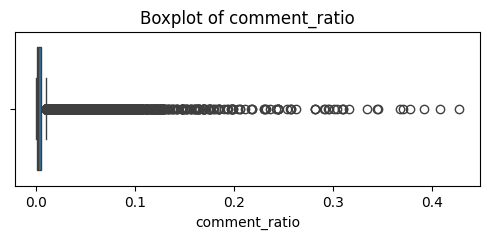

In [ ]:
for col in num_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

###3.2 Categorical Features

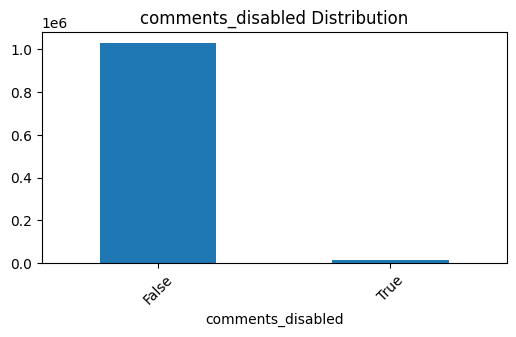

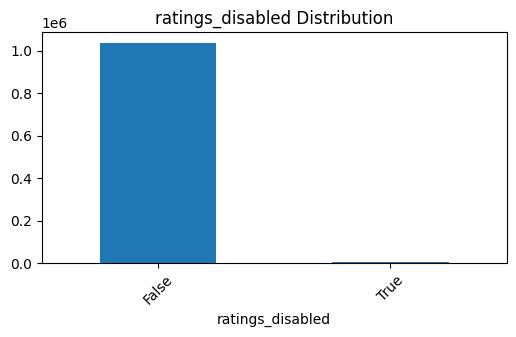

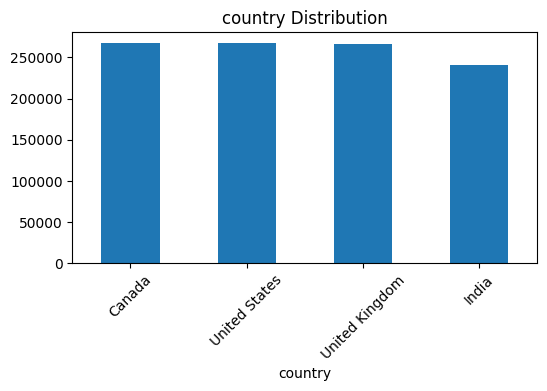

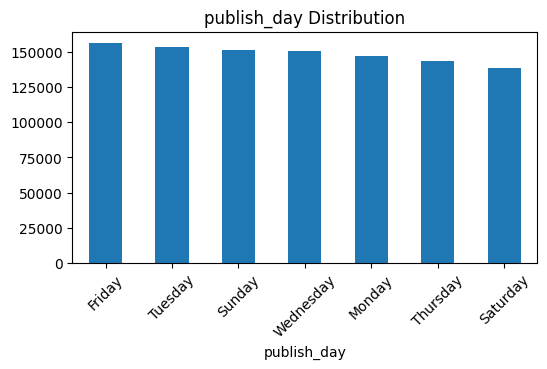

In [ ]:
cat_small = [col for col in cat_cols if df[col].nunique() < 20]

for col in cat_small:
    plt.figure(figsize=(6,3))
    df[col].value_counts().plot(kind='bar')
    plt.title(f'{col} Distribution')
    plt.xticks(rotation=45)
    plt.show()

##04. BIVARIATE ANALYSIS

###4.1 Numerical vs Numerical

####Correlation Heatmap

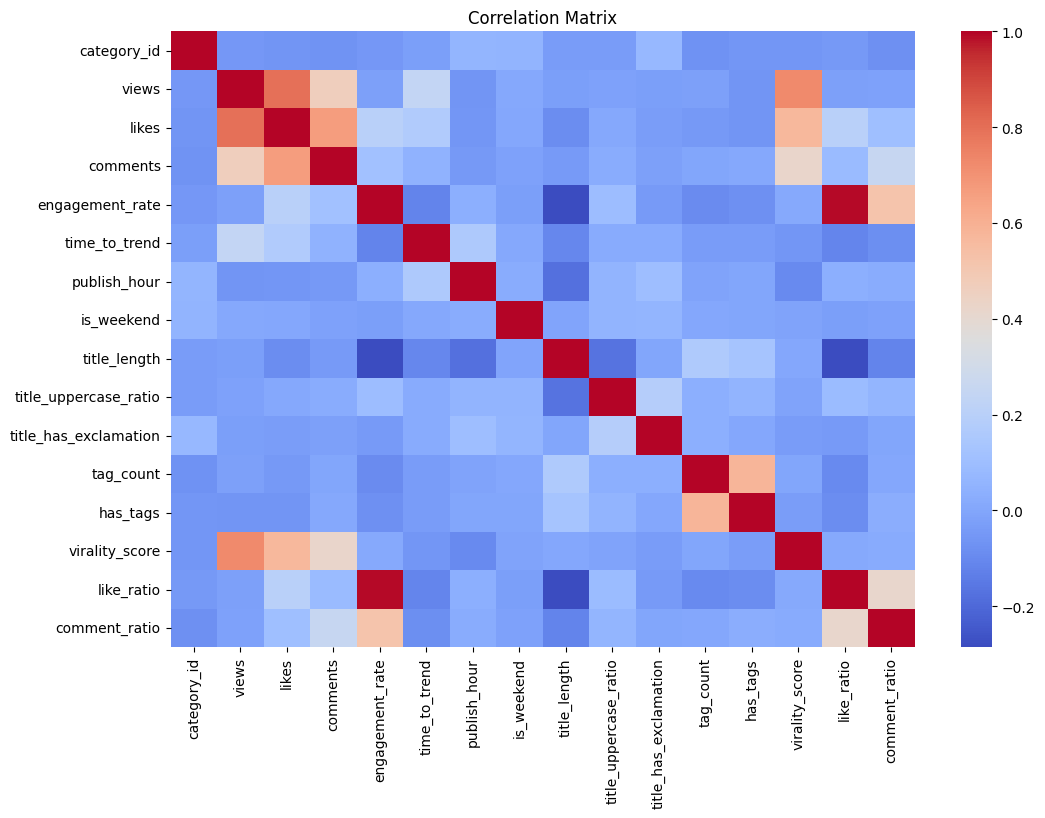

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df[num_cols].corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

####Scatter Plots

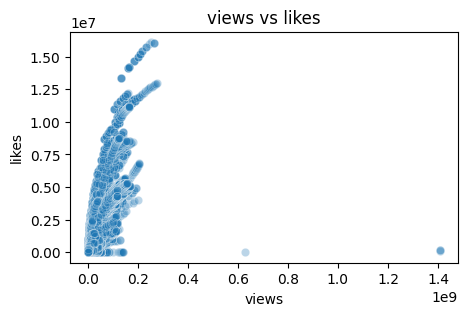

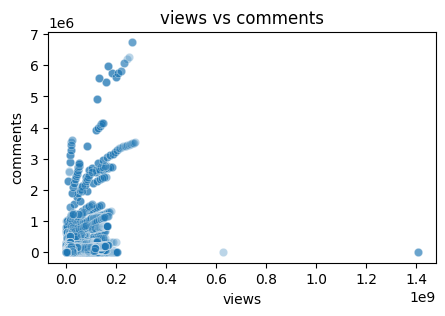

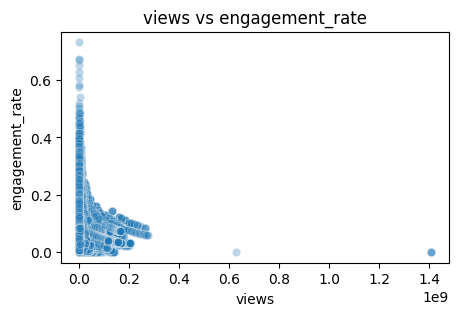

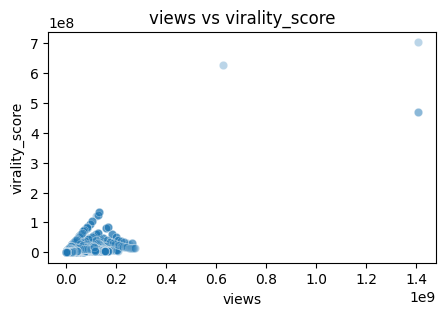

In [ ]:
pairs = [
    ('views','likes'),
    ('views','comments'),
    ('views','engagement_rate'),
    ('views','virality_score')
]

for x,y in pairs:
    plt.figure(figsize=(5,3))
    sns.scatterplot(x=df[x], y=df[y], alpha=0.3)
    plt.title(f"{x} vs {y}")
    plt.show()

###4.2 Categorical vs Numerical

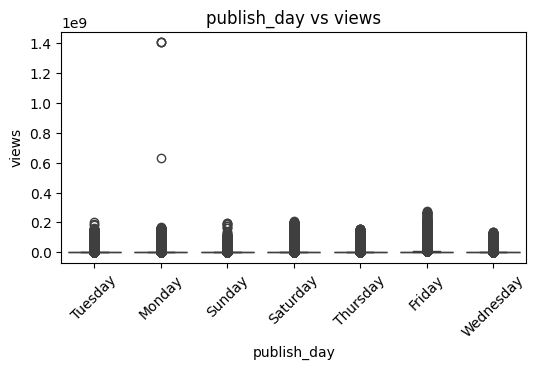

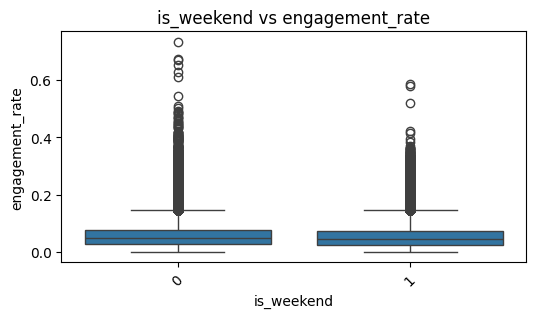

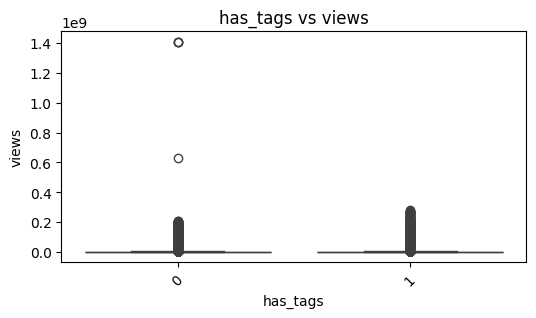

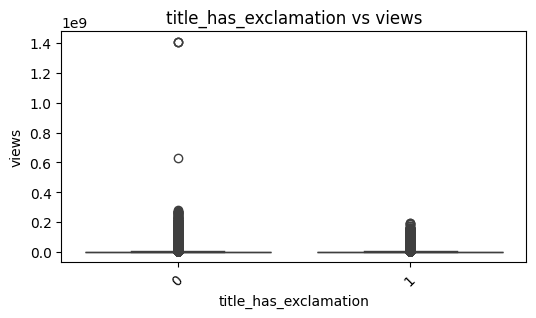

In [ ]:
cat_num_pairs = [
    ('publish_day','views'),
    ('is_weekend','engagement_rate'),
    ('has_tags','views'),
    ('title_has_exclamation','views')
]

for cat, num in cat_num_pairs:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[cat], y=df[num])
    plt.title(f"{cat} vs {num}")
    plt.xticks(rotation=45)
    plt.show()

###4.3 Categorical vs Categorical

In [ ]:
pd.crosstab(df['is_weekend'], df['has_tags'], normalize='index')

has_tags,0,1
is_weekend,,
0,0.166341,0.833659
1,0.167371,0.832629


##05. MULTIVARIATE ANALYSIS

###5.1 Pairplot (sample)

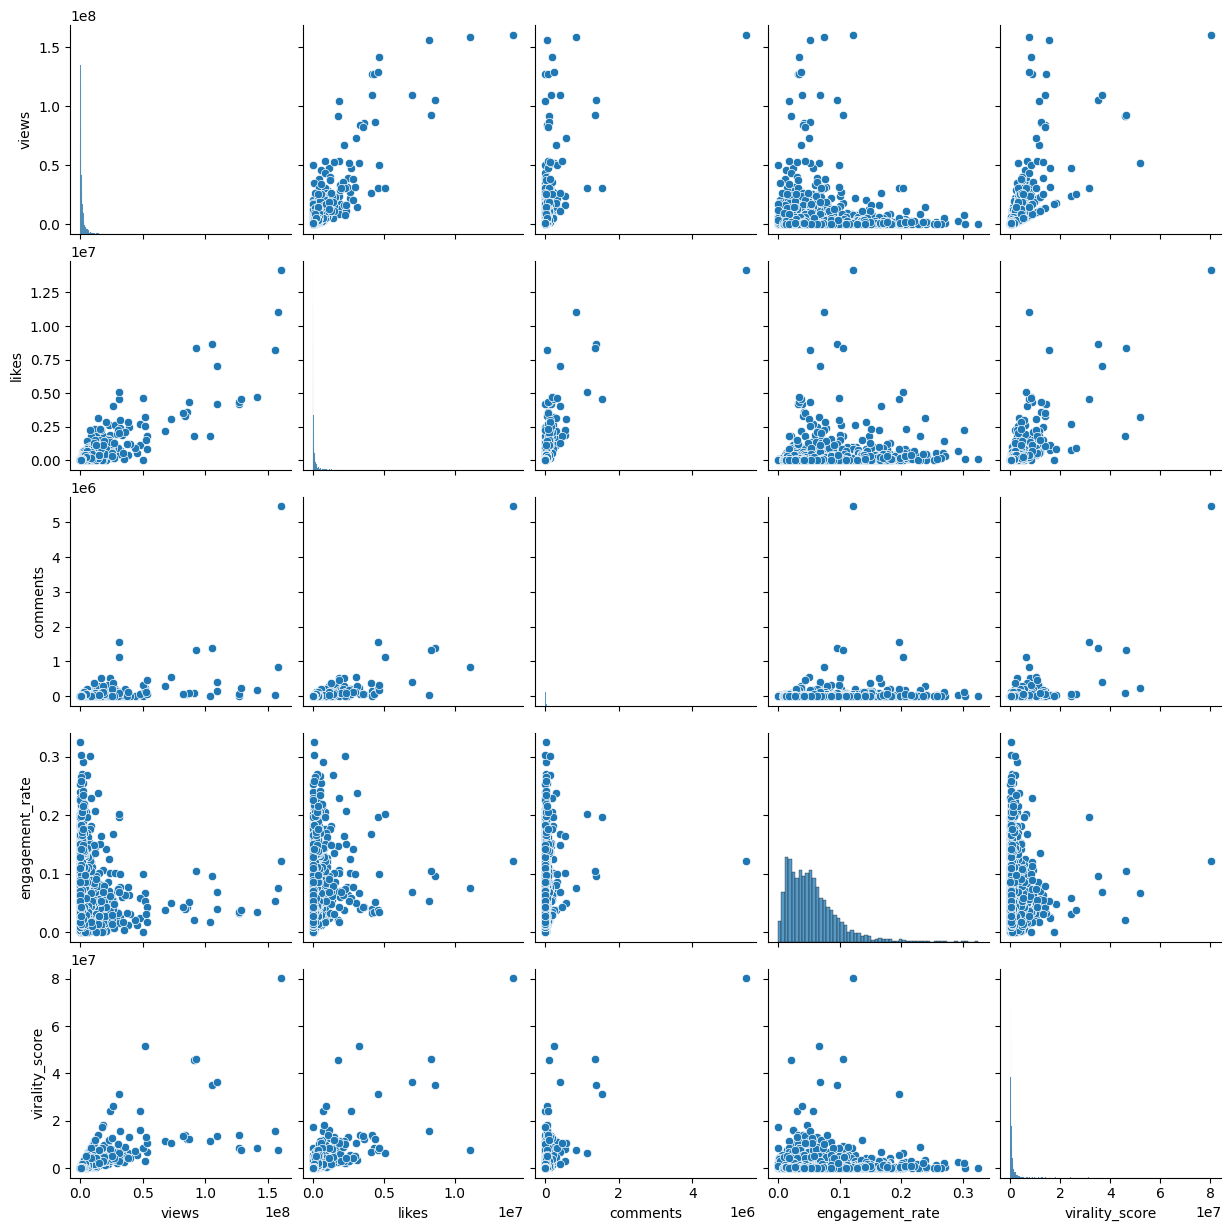

In [ ]:
sample_df = df.sample(5000)

sns.pairplot(sample_df[['views','likes','comments','engagement_rate','virality_score']])
plt.show()

###5.2 Category-Level Analysis

In [ ]:
category_analysis = df.groupby('category_id')[['views','engagement_rate','virality_score']].mean()

category_analysis.sort_values(by='virality_score', ascending=False)

,views,engagement_rate,virality_score
category_id,,,
10,4.703684e+06,0.072314,1.417028e+06
1,3.269037e+06,0.056349,9.776351e+05
24,3.176684e+06,0.051062,9.164663e+05
28,2.634046e+06,0.057645,8.491155e+05
29,2.345575e+06,0.072373,6.277058e+05
22,2.042320e+06,0.064142,6.115491e+05
23,2.028927e+06,0.080108,5.633832e+05
20,1.633045e+06,0.059518,5.079739e+05
17,1.537825e+06,0.025465,4.976204e+05


###5.3 Time-Based Patterns

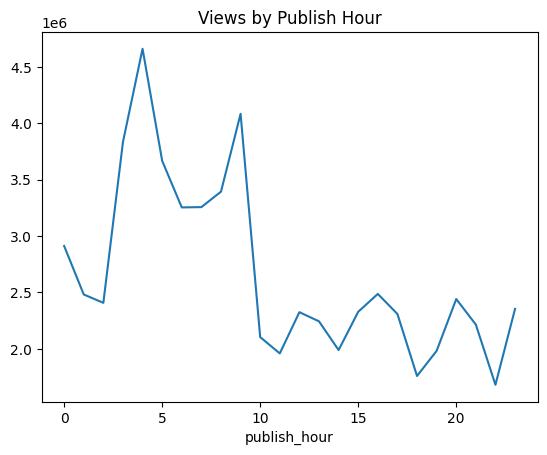

In [ ]:
hour_analysis = df.groupby('publish_hour')['views'].mean()

hour_analysis.plot()
plt.title("Views by Publish Hour")
plt.show()

###5.4 Funnel View

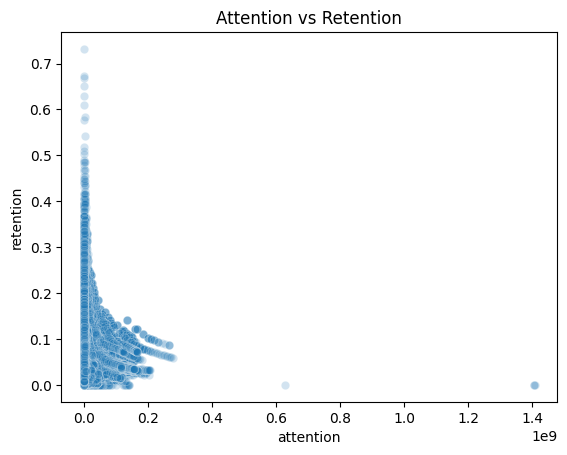

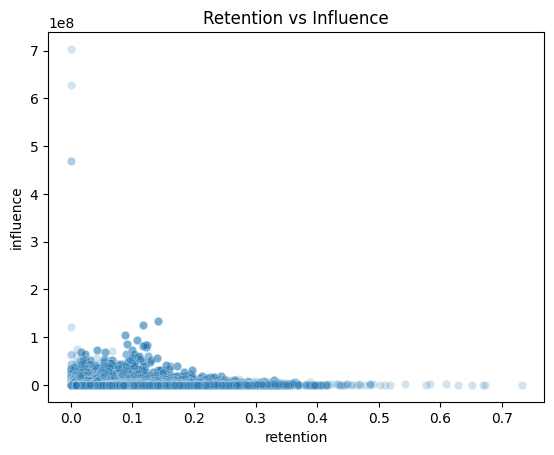

In [ ]:
df['attention'] = df['views']
df['retention'] = df['engagement_rate']
df['influence'] = df['virality_score']

sns.scatterplot(x='attention', y='retention', data=df, alpha=0.2)
plt.title("Attention vs Retention")
plt.show()

sns.scatterplot(x='retention', y='influence', data=df, alpha=0.2)
plt.title("Retention vs Influence")
plt.show()

##Country-wise Analysis

In [ ]:
# Country-wise basic analysis

df.groupby('country')[['views','likes','comments','engagement_rate']].mean().sort_values(by='views', ascending=False)



,views,likes,comments,engagement_rate
country,,,,
India,2.869023e+06,140715.017416,8223.962982,0.055409
United States,2.740394e+06,131308.653948,10067.233620,0.055863
Canada,2.405316e+06,119741.424398,8707.191576,0.056864
United Kingdom,2.197483e+06,107853.076927,7888.038310,0.052914


In [ ]:
df['country'].value_counts()




,count
country,
Canada,267518
United States,267477
United Kingdom,266747
India,240642


In [ ]:
df.to_csv("/content/drive/MyDrive/DVA_Project/data/processed/edadataset.csv", index=False)